In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import ttest_ind
import seaborn as sns
import warnings as ws
ws.filterwarnings('ignore')

In [2]:
# ---------------- Load Data ----------------
dataset = pd.read_csv("Pancreatic_Cancer.csv")
dataset

,Patient_ID,Demographic_1,Demographic_2,Demographic_3,Demographic_4,Demographic_5,Demographic_6,Demographic_7,Demographic_8,Demographic_9,...,Genetic_7,Genetic_8,Genetic_9,Genetic_10,Risk_1,Risk_2,Risk_3,Risk_4,Risk_5,Cancer_Stage
0,PC000001,12.95,6.03,26.04,2.90,21.44,14.63,2.32,20.30,1.50,...,15.96,4.14,25.37,2.49,2.69,8.35,6.49,13.60,2.10,Healthy
1,PC000002,0.01,6.05,4.06,14.54,1.02,34.97,24.56,5.94,10.09,...,21.27,20.94,0.75,17.60,7.32,0.16,31.97,6.89,18.94,Healthy
2,PC000003,29.01,22.26,13.04,20.73,22.22,31.37,4.24,22.41,9.94,...,18.99,37.39,4.25,32.76,17.29,19.80,33.38,15.72,20.27,Healthy
3,PC000004,27.51,39.30,13.71,33.29,28.27,25.44,16.19,13.90,2.18,...,18.59,18.65,4.74,35.75,7.97,39.13,37.45,0.70,18.36,Healthy
4,PC000005,32.80,38.72,17.98,10.75,8.39,37.82,8.43,23.26,5.67,...,28.38,35.83,18.93,23.49,0.01,15.66,37.07,33.02,34.22,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,PC059996,96.41,125.47,8.79,45.86,80.52,25.35,73.54,40.22,45.90,...,47.56,80.76,17.38,124.89,60.15,38.87,113.66,11.36,64.49,Stage IV
59996,PC059997,112.86,79.98,26.03,42.83,120.30,34.89,121.25,52.08,118.62,...,75.81,69.73,32.63,93.49,32.83,28.21,75.68,83.28,84.55,Stage IV
59997,PC059998,92.03,116.48,42.54,26.40,87.23,66.82,32.16,43.93,76.39,...,22.66,48.25,104.37,17.66,39.18,77.80,49.11,72.92,21.91,Stage IV
59998,PC059999,14.27,38.09,23.87,122.81,35.86,39.87,46.73,52.67,43.35,...,87.79,4.54,89.95,35.54,63.08,109.71,118.98,115.20,101.42,Stage IV


In [3]:
# ---------------- Data Cleaning ----------------
print("Duplicates:", dataset.duplicated().sum())
dataset = dataset.drop_duplicates()   # actually remove them if any exist

Duplicates: 0


In [4]:
print("Missing values:\n", dataset.isnull().sum())

Missing values:
 Patient_ID       0
Demographic_1    0
Demographic_2    0
Demographic_3    0
Demographic_4    0
                ..
Risk_2           0
Risk_3           0
Risk_4           0
Risk_5           0
Cancer_Stage     0
Length: 132, dtype: int64


In [5]:
# ---------------- Encode Target (Ordinal - has natural order) ----------------
# One-Hot Encoding for categorical data - Newyork, Texas, New jersey
# Label Encoding-  Binary categories like yes/No, True/False
# Ordinal Encoding - low, high, medium
# Here predict different stages of disease present or not. use Ordinal Encoding
stageOrder = [['Healthy', 'High Risk', 'Stage I', 'Stage II', 'Stage III', 'Stage IV']]
encoder = OrdinalEncoder(categories=stageOrder)
dataset['Cancer_Stage'] = encoder.fit_transform(dataset[['Cancer_Stage']])

In [6]:
dataset

,Patient_ID,Demographic_1,Demographic_2,Demographic_3,Demographic_4,Demographic_5,Demographic_6,Demographic_7,Demographic_8,Demographic_9,...,Genetic_7,Genetic_8,Genetic_9,Genetic_10,Risk_1,Risk_2,Risk_3,Risk_4,Risk_5,Cancer_Stage
0,PC000001,12.95,6.03,26.04,2.90,21.44,14.63,2.32,20.30,1.50,...,15.96,4.14,25.37,2.49,2.69,8.35,6.49,13.60,2.10,0.0
1,PC000002,0.01,6.05,4.06,14.54,1.02,34.97,24.56,5.94,10.09,...,21.27,20.94,0.75,17.60,7.32,0.16,31.97,6.89,18.94,0.0
2,PC000003,29.01,22.26,13.04,20.73,22.22,31.37,4.24,22.41,9.94,...,18.99,37.39,4.25,32.76,17.29,19.80,33.38,15.72,20.27,0.0
3,PC000004,27.51,39.30,13.71,33.29,28.27,25.44,16.19,13.90,2.18,...,18.59,18.65,4.74,35.75,7.97,39.13,37.45,0.70,18.36,0.0
4,PC000005,32.80,38.72,17.98,10.75,8.39,37.82,8.43,23.26,5.67,...,28.38,35.83,18.93,23.49,0.01,15.66,37.07,33.02,34.22,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,PC059996,96.41,125.47,8.79,45.86,80.52,25.35,73.54,40.22,45.90,...,47.56,80.76,17.38,124.89,60.15,38.87,113.66,11.36,64.49,5.0
59996,PC059997,112.86,79.98,26.03,42.83,120.30,34.89,121.25,52.08,118.62,...,75.81,69.73,32.63,93.49,32.83,28.21,75.68,83.28,84.55,5.0
59997,PC059998,92.03,116.48,42.54,26.40,87.23,66.82,32.16,43.93,76.39,...,22.66,48.25,104.37,17.66,39.18,77.80,49.11,72.92,21.91,5.0
59998,PC059999,14.27,38.09,23.87,122.81,35.86,39.87,46.73,52.67,43.35,...,87.79,4.54,89.95,35.54,63.08,109.71,118.98,115.20,101.42,5.0


In [7]:
# ---------------- Drop ID column ----------------
dataset = dataset.drop(columns=['Patient_ID'])

In [8]:
# ---------------- Identify categorical columns (before encoding) ----------------
quali_cols = dataset.select_dtypes(include='object').columns.tolist()
quan_cols = dataset.select_dtypes(exclude='object').columns.tolist()

In [9]:
# ---------------- Encode remaining categorical features (One-Hot encoding) ----------------
dataset = pd.get_dummies(dataset, drop_first=True, dtype=int)

In [10]:
# ---------------- Split Input / Output ----------------
independent = dataset.drop(columns=["Cancer_Stage"])
dependent = dataset["Cancer_Stage"]

X_train, X_test, Y_train, Y_test = train_test_split(
    independent, dependent, test_size=0.30, random_state=0
)



In [11]:
X_train

,Demographic_1,Demographic_2,Demographic_3,Demographic_4,Demographic_5,Demographic_6,Demographic_7,Demographic_8,Demographic_9,Demographic_10,...,Genetic_6,Genetic_7,Genetic_8,Genetic_9,Genetic_10,Risk_1,Risk_2,Risk_3,Risk_4,Risk_5
7927,37.03,21.09,12.01,22.64,2.55,37.75,13.10,27.83,25.21,18.29,...,14.37,25.54,14.59,4.27,2.63,11.37,29.37,10.14,13.63,39.95
5212,23.55,11.06,17.58,30.14,29.38,29.35,8.21,17.95,31.24,1.00,...,0.77,0.58,27.06,19.30,29.70,31.09,23.44,32.43,15.09,4.07
28581,31.96,7.68,22.58,59.74,50.02,46.20,13.39,40.51,33.31,0.69,...,7.78,54.63,45.29,41.39,37.86,53.59,39.45,30.94,20.03,59.79
39089,36.03,68.90,24.05,74.24,17.63,8.71,31.88,28.76,8.97,21.88,...,68.26,28.49,39.38,23.34,58.61,7.63,45.72,64.75,10.97,74.43
52059,51.88,33.34,87.22,32.76,32.64,81.67,64.27,54.01,2.21,51.21,...,88.96,61.13,64.50,4.29,21.10,29.70,63.07,39.51,98.03,19.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45891,70.99,71.53,65.02,4.62,3.23,15.41,47.39,61.51,59.58,79.18,...,60.64,64.23,35.35,10.81,7.42,40.71,10.33,19.35,8.62,1.83
52416,78.10,29.99,9.94,81.19,84.25,48.92,10.39,52.63,16.64,56.79,...,58.07,88.94,42.35,16.83,54.65,16.35,28.61,76.93,57.86,45.72
42613,46.69,34.55,49.32,71.91,17.82,0.68,27.04,1.50,59.48,3.81,...,8.84,24.22,38.34,18.54,8.87,36.42,17.54,28.10,29.65,31.78
43567,47.89,23.23,20.26,41.94,11.08,17.17,66.46,57.54,15.74,44.59,...,3.15,4.64,4.47,53.30,32.36,70.68,3.70,77.38,17.04,2.63


In [12]:
Y_train

7927     0.0
5212     0.0
28581    1.0
39089    2.0
52059    3.0
        ... 
45891    2.0
52416    3.0
42613    2.0
43567    2.0
2732     0.0
Name: Cancer_Stage, Length: 42000, dtype: float64

In [13]:
X_test

,Demographic_1,Demographic_2,Demographic_3,Demographic_4,Demographic_5,Demographic_6,Demographic_7,Demographic_8,Demographic_9,Demographic_10,...,Genetic_6,Genetic_7,Genetic_8,Genetic_9,Genetic_10,Risk_1,Risk_2,Risk_3,Risk_4,Risk_5
3048,2.43,12.65,23.96,31.04,14.34,2.87,7.23,10.73,21.69,20.96,...,29.67,38.04,7.07,20.75,39.90,26.55,33.78,37.43,18.92,16.33
19563,25.39,5.27,12.98,33.16,4.92,20.66,1.68,13.28,10.44,4.72,...,17.68,22.55,15.52,2.84,36.66,28.80,31.19,21.00,23.51,18.57
58303,15.65,54.49,7.77,87.63,110.36,77.74,86.76,30.12,43.43,102.53,...,15.37,121.29,34.02,104.42,59.02,38.28,125.37,80.20,70.53,124.15
8870,32.91,33.51,2.17,37.82,1.76,17.06,24.53,12.29,15.57,38.35,...,8.98,5.96,36.35,6.29,10.42,23.64,19.08,4.87,17.41,22.77
40228,54.84,49.84,26.03,60.38,28.98,13.14,45.25,26.99,12.72,5.16,...,66.95,44.01,55.07,37.24,73.16,0.17,62.27,0.43,14.54,10.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55015,90.04,23.60,9.75,1.28,27.90,3.71,3.03,48.77,112.19,61.93,...,86.68,38.53,65.82,58.06,25.14,88.07,72.57,25.33,103.21,93.83
58445,109.37,126.12,3.09,31.69,89.17,25.10,38.90,82.28,85.19,59.50,...,67.44,102.03,122.72,120.95,29.31,24.80,7.03,81.35,54.02,102.08
14320,29.59,9.92,38.14,32.67,3.51,4.64,23.77,34.84,39.63,5.27,...,20.62,17.87,32.37,16.89,29.58,16.15,24.35,17.38,22.28,17.02
43696,69.46,46.78,47.35,36.28,64.81,8.51,11.85,2.61,9.38,29.69,...,38.01,55.40,23.07,68.33,47.34,28.58,9.95,29.30,36.01,4.80


In [14]:
Y_test


3048     0.0
19563    0.0
58303    5.0
8870     0.0
40228    2.0
        ... 
55015    4.0
58445    5.0
14320    0.0
43696    2.0
10160    0.0
Name: Cancer_Stage, Length: 18000, dtype: float64

In [15]:
# ---------------- Scale ----------------
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [16]:
# ---------------- Handle Class Imbalance (train set only) ----------------
smote = SMOTE(random_state=42)
X_train_balance, Y_train_balance = smote.fit_resample(X_train_scaled, Y_train)
#  X_train_balance is now a DataFrame with proper column names, since SMOTE preserves DataFrame input


In [17]:
# ---------------- Feature Selection ----------------
selector = SelectKBest(score_func=f_classif, k=7)
X_train_selected = selector.fit_transform(X_train_balance, Y_train_balance)
X_test_selected = selector.transform(X_test_scaled)

In [18]:
selected_features = X_train.columns[selector.get_support()]

print(selected_features)

Index(['History_2', 'Symptom_3', 'Imaging_12', 'Biomarker_5', 'Biomarker_7',
       'Genetic_4', 'Risk_3'],
      dtype='object')


In [19]:
selected_dataset = dataset[selected_features.tolist() + ["Cancer_Stage"]]

In [20]:
selected_dataset

,History_2,Symptom_3,Imaging_12,Biomarker_5,Biomarker_7,Genetic_4,Risk_3,Cancer_Stage
0,11.58,31.78,0.16,27.62,24.70,34.98,6.49,0.0
1,38.04,34.11,10.07,16.76,36.40,16.83,31.97,0.0
2,37.66,26.41,2.02,11.60,7.12,29.32,33.38,0.0
3,17.83,1.67,25.71,12.18,0.50,27.03,37.45,0.0
4,12.08,11.01,38.71,8.64,9.94,34.92,37.07,0.0
...,...,...,...,...,...,...,...,...
59995,98.51,102.94,10.05,43.11,13.75,28.13,113.66,5.0
59996,66.48,91.37,57.60,40.62,87.19,98.82,75.68,5.0
59997,98.18,14.55,3.68,123.71,68.54,13.04,49.11,5.0
59998,47.67,74.06,124.90,1.38,62.63,31.64,118.98,5.0


In [21]:
selected_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   History_2     60000 non-null  float64
 1   Symptom_3     60000 non-null  float64
 2   Imaging_12    60000 non-null  float64
 3   Biomarker_5   60000 non-null  float64
 4   Biomarker_7   60000 non-null  float64
 5   Genetic_4     60000 non-null  float64
 6   Risk_3        60000 non-null  float64
 7   Cancer_Stage  60000 non-null  float64
dtypes: float64(8)
memory usage: 3.7 MB


In [22]:
selected_dataset.describe()

,History_2,Symptom_3,Imaging_12,Biomarker_5,Biomarker_7,Genetic_4,Risk_3,Cancer_Stage
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,33.345222,33.452046,33.516328,33.467255,33.443553,33.566212,33.462531,1.391667
std,25.128162,25.222588,25.208550,25.205253,25.323440,25.225153,25.280183,1.490515
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.070000,14.330000,14.130000,14.210000,14.110000,14.290000,14.290000,0.000000
50%,28.380000,28.500000,28.480000,28.570000,28.325000,28.590000,28.390000,1.000000
75%,46.310000,46.160000,46.360000,46.370000,46.260000,46.530000,46.170000,2.000000
max,126.890000,126.910000,126.980000,126.820000,127.000000,126.990000,126.960000,5.000000


In [23]:
selected_dataset.corr(numeric_only=True)

,History_2,Symptom_3,Imaging_12,Biomarker_5,Biomarker_7,Genetic_4,Risk_3,Cancer_Stage
History_2,1.000000,0.313880,0.314245,0.313564,0.312298,0.312814,0.308143,0.554427
Symptom_3,0.313880,1.000000,0.322932,0.313825,0.316322,0.314344,0.317681,0.559228
Imaging_12,0.314245,0.322932,1.000000,0.312493,0.319505,0.322306,0.308577,0.560100
Biomarker_5,0.313564,0.313825,0.312493,1.000000,0.308308,0.311442,0.318722,0.558356
Biomarker_7,0.312298,0.316322,0.319505,0.308308,1.000000,0.315614,0.310684,0.560201
Genetic_4,0.312814,0.314344,0.322306,0.311442,0.315614,1.000000,0.309595,0.558293
Risk_3,0.308143,0.317681,0.308577,0.318722,0.310684,0.309595,1.000000,0.558544
Cancer_Stage,0.554427,0.559228,0.560100,0.558356,0.560201,0.558293,0.558544,1.000000


In [24]:
selected_dataset.cov(numeric_only=True)

,History_2,Symptom_3,Imaging_12,Biomarker_5,Biomarker_7,Genetic_4,Risk_3,Cancer_Stage
History_2,631.424531,198.936281,199.056740,198.599359,198.724824,198.280570,195.745992,20.765468
Symptom_3,198.936281,636.178962,205.328428,199.511567,202.041945,199.999340,202.563233,21.023959
Imaging_12,199.056740,205.328428,635.470977,198.554117,203.961746,204.950931,196.649102,21.045021
Biomarker_5,198.599359,199.511567,198.554117,635.304781,196.788266,198.016583,203.087510,20.976763
Biomarker_7,198.724824,202.041945,203.961746,196.788266,641.276620,201.610469,198.893806,21.144751
Genetic_4,198.280570,199.999340,204.950931,198.016583,201.610469,636.308323,197.427660,20.990971
Risk_3,195.745992,202.563233,196.649102,203.087510,198.893806,197.427660,639.087648,21.046200
Cancer_Stage,20.765468,21.023959,21.045021,20.976763,21.144751,20.990971,21.046200,2.221634


array([[<Axes: title={'center': 'History_2'}>,
        <Axes: title={'center': 'Symptom_3'}>,
        <Axes: title={'center': 'Imaging_12'}>],
       [<Axes: title={'center': 'Biomarker_5'}>,
        <Axes: title={'center': 'Biomarker_7'}>,
        <Axes: title={'center': 'Genetic_4'}>],
       [<Axes: title={'center': 'Risk_3'}>,
        <Axes: title={'center': 'Cancer_Stage'}>, <Axes: >]], dtype=object)

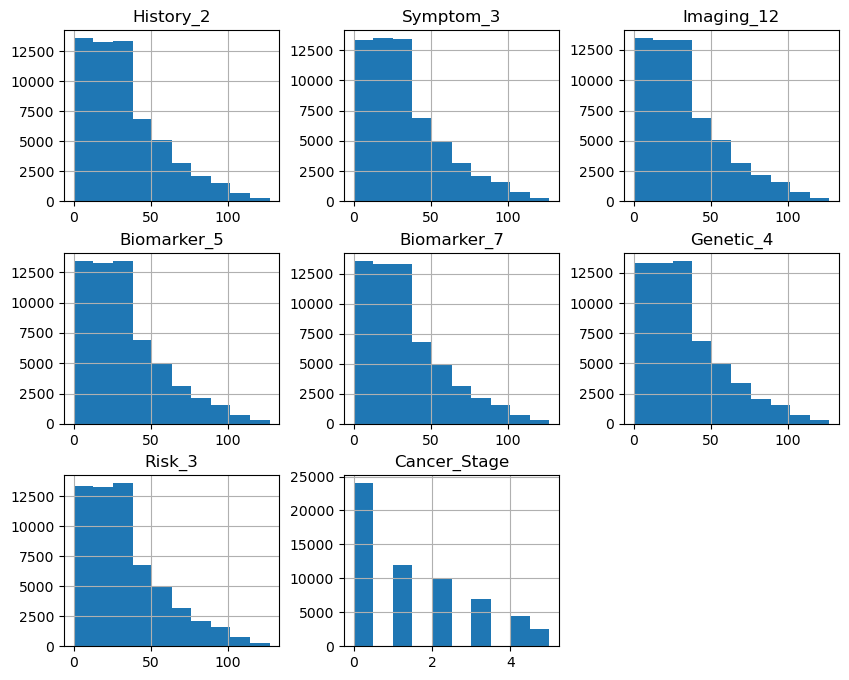

In [25]:
selected_dataset.hist(figsize=(10,8))

In [26]:
# ---------------- Calculate Central Dependency ----------------
X_selected = selected_dataset.drop(columns=["Cancer_Stage"]).columns
descriptive = pd.DataFrame(index=["Mean", "Median", "Mode", "Q1:25%", "Q2:50%", "Q3:75%","Max", "IQR", "1.5Rule","Lesser","Greater","Min","Max","Skew","Kurtosis",'Var', 'StdVar',"Values","Frequency", "Relative Frequency", "Cusum Frequency"], columns=X_selected)
for colName in X_selected:            
     descriptive[colName]["Mean"]= dataset[colName].mean()
     descriptive[colName]["Median"]=  dataset[colName].median()
     descriptive[colName]["Mode"]=  dataset[colName].mode()[0]
     descriptive[colName]["Q1:25%"]=  dataset.describe()[colName]["25%"]
     descriptive[colName]["Q2:50%"]= dataset.describe()[colName]["50%"]
     descriptive[colName]["Q3:75%"]= dataset.describe()[colName]["75%"]             
     descriptive[colName]["Max"]=  dataset.describe()[colName]["max"]
     descriptive[colName]["IQR"]=  descriptive[colName]["Q3:75%"] - descriptive[colName]["Q1:25%"]
     descriptive[colName]["1.5Rule"] = 1.5 * descriptive[colName]["IQR"]
     descriptive[colName]["Lesser"] =descriptive[colName]["Q1:25%"]-descriptive[colName]["1.5Rule"]
     descriptive[colName]["Greater"] = descriptive[colName]["Q3:75%"]+ descriptive[colName]["1.5Rule"]
     descriptive[colName]["Min"]=dataset[colName].min()
     descriptive[colName]["Max"]=dataset[colName].max()
     descriptive[colName]["Skew"]=dataset[colName].skew()
     descriptive[colName]["Kurtosis"]=dataset[colName].kurtosis()
     descriptive[colName]["Var"]=dataset[colName].var()
     descriptive[colName]["StdVar"]=dataset[colName].std()
     descriptive[colName]["Values"] = dataset[colName].value_counts().index
     descriptive[colName]["Frequency"] = dataset[colName].value_counts().values
     tableLength = len( descriptive[colName]["Values"])
     descriptive[colName]["Relative Frequency"]= descriptive[colName]["Frequency"]/tableLength
     descriptive [colName]["Cusum Frequency"]= descriptive[colName]["Relative Frequency"].cumsum()


In [27]:
descriptive

,History_2,Symptom_3,Imaging_12,Biomarker_5,Biomarker_7,Genetic_4,Risk_3
Mean,33.345222,33.452046,33.516328,33.467255,33.443553,33.566212,33.462531
Median,28.38,28.5,28.48,28.57,28.325,28.59,28.39
Mode,13.6,11.29,35.74,3.17,25.72,38.02,10.74
Q1:25%,14.07,14.33,14.13,14.21,14.11,14.29,14.29
Q2:50%,28.38,28.5,28.48,28.57,28.325,28.59,28.39
Q3:75%,46.31,46.16,46.36,46.37,46.26,46.53,46.17
Max,126.89,126.91,126.98,126.82,127.0,126.99,126.96
IQR,32.24,31.83,32.23,32.16,32.15,32.24,31.88
1.5Rule,48.36,47.745,48.345,48.24,48.225,48.36,47.82
Lesser,-34.29,-33.415,-34.215,-34.03,-34.115,-34.07,-33.53


In [28]:
def calc_vif(X):
    
    #Creates an empty DataFrame to store the results. 
    vif= pd.DataFrame()
    # Gets all column names from X.
    vif["Vaiables"]=X.columns
    #Shapes return row and columns
    #shape[1] picks out just the number of columns.
    # x.values - Converts the DataFrame X into a plain NumPy array
    # variance_inflation_factor(X.values, i) - Calculates the VIF for the column at index i by regressing it against all the other independent variables.
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return(vif)

In [29]:
# ---------------- Calculates the VIF for detect the multicolinearity----------------
calc_vif(selected_dataset.iloc[:, :].corr(numeric_only=True))

,Vaiables,VIF
0,History_2,5.110050
1,Symptom_3,5.232241
2,Imaging_12,5.263752
3,Biomarker_5,5.237352
4,Biomarker_7,5.293708
5,Genetic_4,5.222760
6,Risk_3,5.253275
7,Cancer_Stage,67.903402


In [30]:
Symptom1= dataset[dataset["Cancer_Stage"]==2.0]["Symptom_3"]
Symptom2=dataset[dataset["Cancer_Stage"]==1.0]["Imaging_12"]
ttest_ind(Symptom1, Symptom2)
# pvalue >0.05. here significant differnce avaiables

TtestResult(statistic=np.float64(36.1106244207179), pvalue=np.float64(1.888664901729766e-277), df=np.float64(21998.0))

In [31]:
Symptom1= dataset[dataset["Cancer_Stage"]==2.0]["History_2"]
Symptom2=dataset[dataset["Cancer_Stage"]==2.0]["Symptom_3"]
ttest_ind(Symptom1, Symptom2)
# pvalue >0.05. here significant differnce avaiables

TtestResult(statistic=np.float64(0.45615437653146035), pvalue=np.float64(0.6482839239729977), df=np.float64(19998.0))

In [32]:
Symptom1= dataset[dataset["Cancer_Stage"]==2.0]["Symptom_3"]
Symptom2=dataset[dataset["Cancer_Stage"]==1.0]["Biomarker_5"]
ttest_ind(Symptom1, Symptom2)
# pvalue >0.05. here significant differnce avaiables

TtestResult(statistic=np.float64(36.63596602714148), pvalue=np.float64(2.769384446101613e-285), df=np.float64(21998.0))

In [33]:
# ---------------- Feature Importance (Random Forest) ----------------
classifier = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
classifier.fit(X_train_selected, Y_train_balance)


,n_estimators,10
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
classifier

,n_estimators,10
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False
